# 04. Institutional Analysis: Municipal (JST) Transactions & Fiscal Balance

This notebook investigates the institutional dimension of the Poznań housing market: transactions conducted by **Local Government Units (Jednostki Samorządu Terytorialnego - JST)**. It contrasts commercial tender sales against statutory tenant discount subsidies (*bonifikaty komunalne*), uncovering the net municipal fiscal balance and spatial capital redistribution.

---

### Institutional Research Scope
1. **Market Comparison:** Compare municipal transaction price dynamics against open-market benchmarks over time (2013–2025).
2. **Dual-Regime Structure:**
   - **Tender Sales (*Przetargi*):** Open auctions generating revenue surpluses above local market benchmarks.
   - **Tenant Discounts (*Bonifikaty*):** Statutory sales to existing municipal tenants at heavy discounts (up to 85–90%).
3. **Geospatial Impact Density:** Kernel Density Estimation (KDE) weighted by financial capital flow across Poznań's urban footprint.
4. **Municipal Fiscal Balance (*Bilans Netto Transakcji JST*):** Net financial balance aggregated by administrative district (*osiedle*), quantifying the fiscal transfer from central commercial tenders to peripheral social housing privatizations.
5. **Portfolio Statistics & Extreme Discount Audit:** Quantification of the aggregate municipal subsidy portfolio and audit of transactions with $>30\%$ discounts.


## 1. Environment & Data Loading
Initialize plotting configurations and load both the municipal JST dataset ($N = 1,664$) and open-market transactions ($N = 38,154$).


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import features
from src.data_io import load_data
from src.reporting import summarize_dataset
from src.viz import set_plot_style
from scripts.jst_wizualizacje import plot_jst_summary

root = project_root
market_path = root / "data" / "processed" / "housing_residential_market.csv"
jst_path = root / "data" / "processed" / "housing_jst_institutional.csv"
raw_path = root / "data" / "rcn_lokale_polaczone_extra_osiedla.csv"

if market_path.exists() and jst_path.exists():
    market = pd.read_csv(market_path)
    jst = pd.read_csv(jst_path)
elif raw_path.exists():
    df_raw = load_data(raw_path)
    market = features.prepare_market_dataframe(df_raw)
    jst = features.prepare_jst_dataframe(df_raw)
else:
    raise FileNotFoundError("Neither processed datasets nor raw cadastral file found in data/.")

df = market
set_plot_style()
summarize_dataset(df)

print(f"market rows: {len(market):,}")
print(f"JST rows: {len(jst):,}")
print(f"median JST price: {jst['cena_za_m2'].median():.1f} PLN/m²")
print(f"median market price: {market['cena_za_m2'].median():.1f} PLN/m²")


market rows: 111,683
JST rows: 62,720
median JST price: 9659.8 PLN/m²
median market price: 9529.8 PLN/m²


## 2. Municipal vs. Open-Market Price Trajectories
Examine annual median price dynamics of municipal transactions relative to open-market arm's-length sales.


In [2]:
jst_by_year = jst.groupby("rok", as_index=False)["cena_za_m2"].median()
jst_by_year.head()


,rok,cena_za_m2
0,2011,9822.763878
1,2012,8984.466829
2,2013,8848.348259
3,2014,8794.667992
4,2015,9094.835705


## 3. Institutional Portfolio Overview
Summary visualizations comparing municipal transaction volume and price distributions across Poznań's administrative districts.


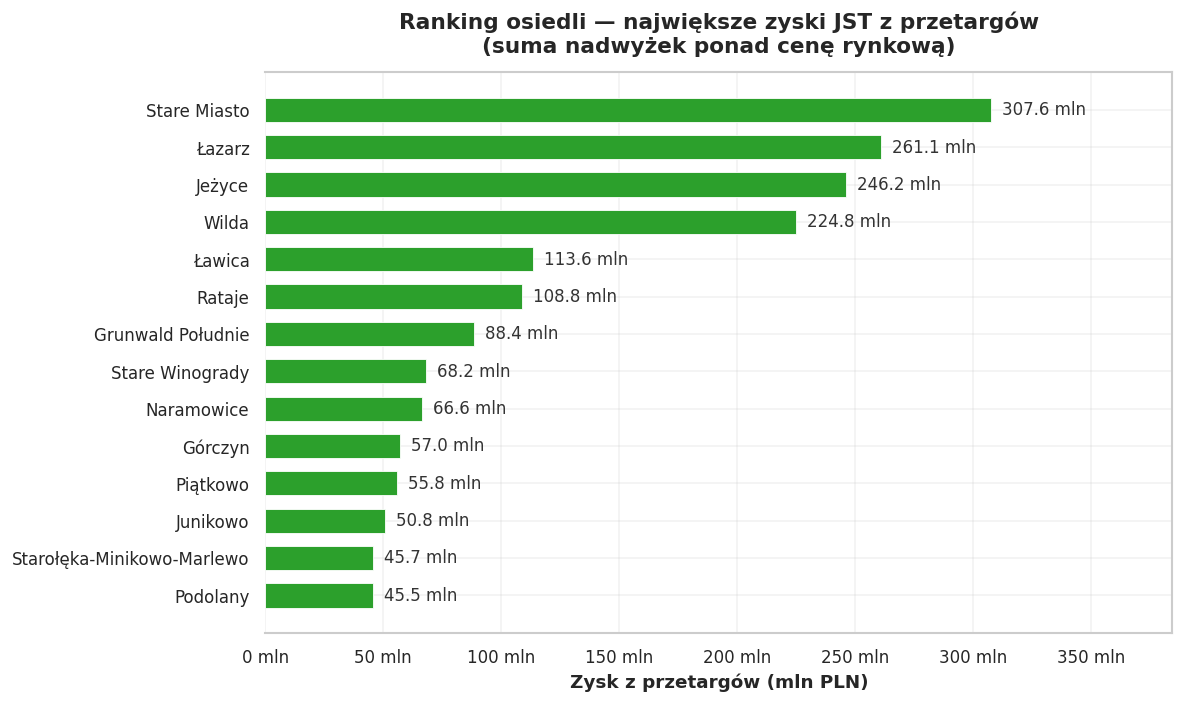

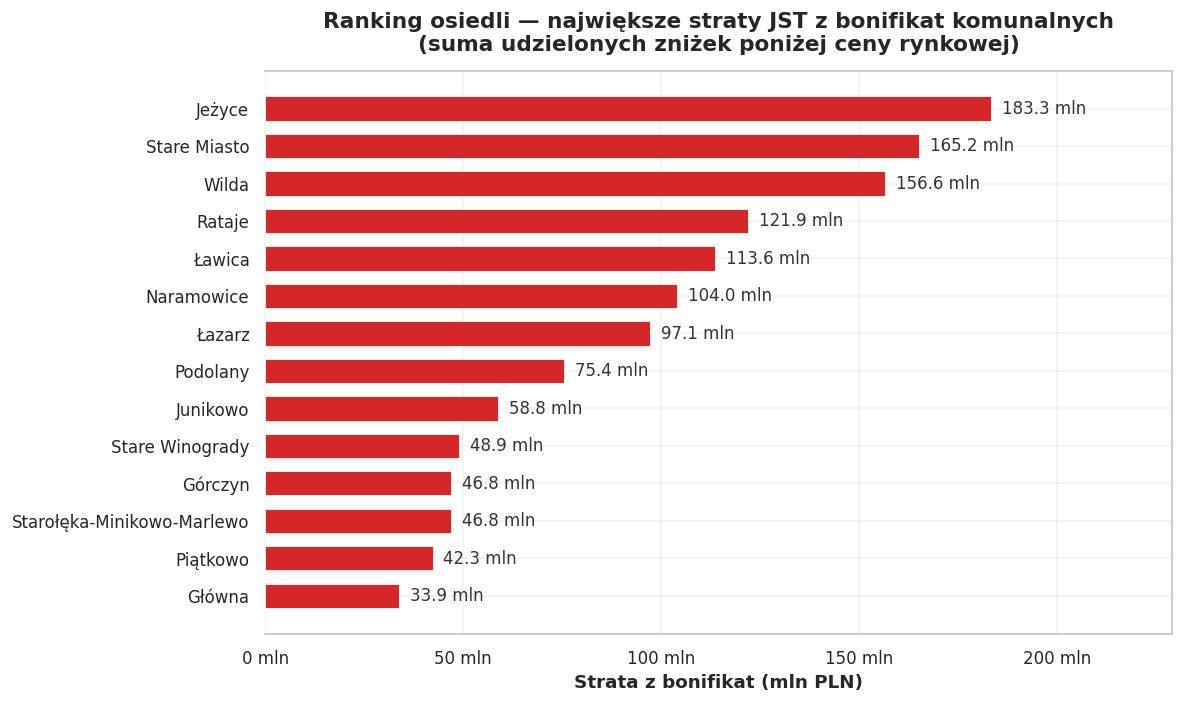

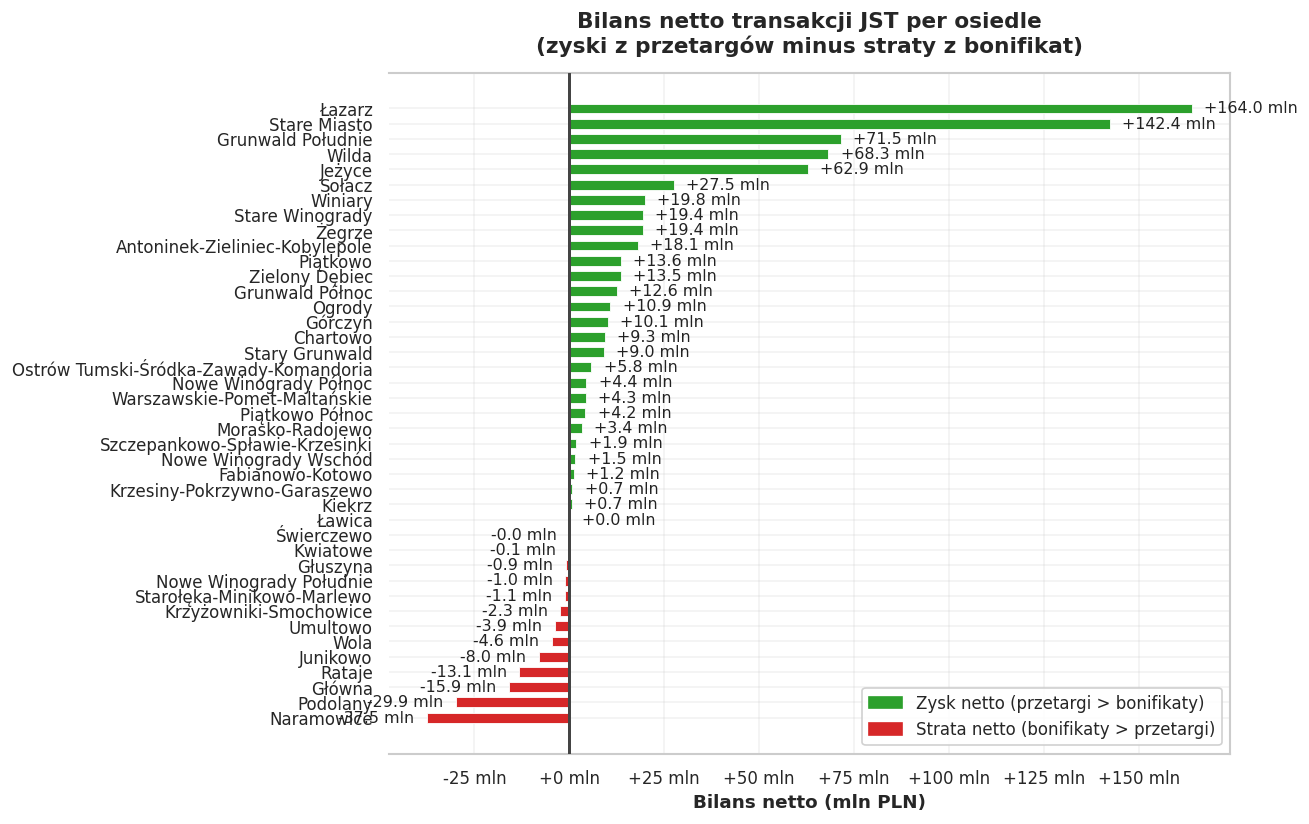

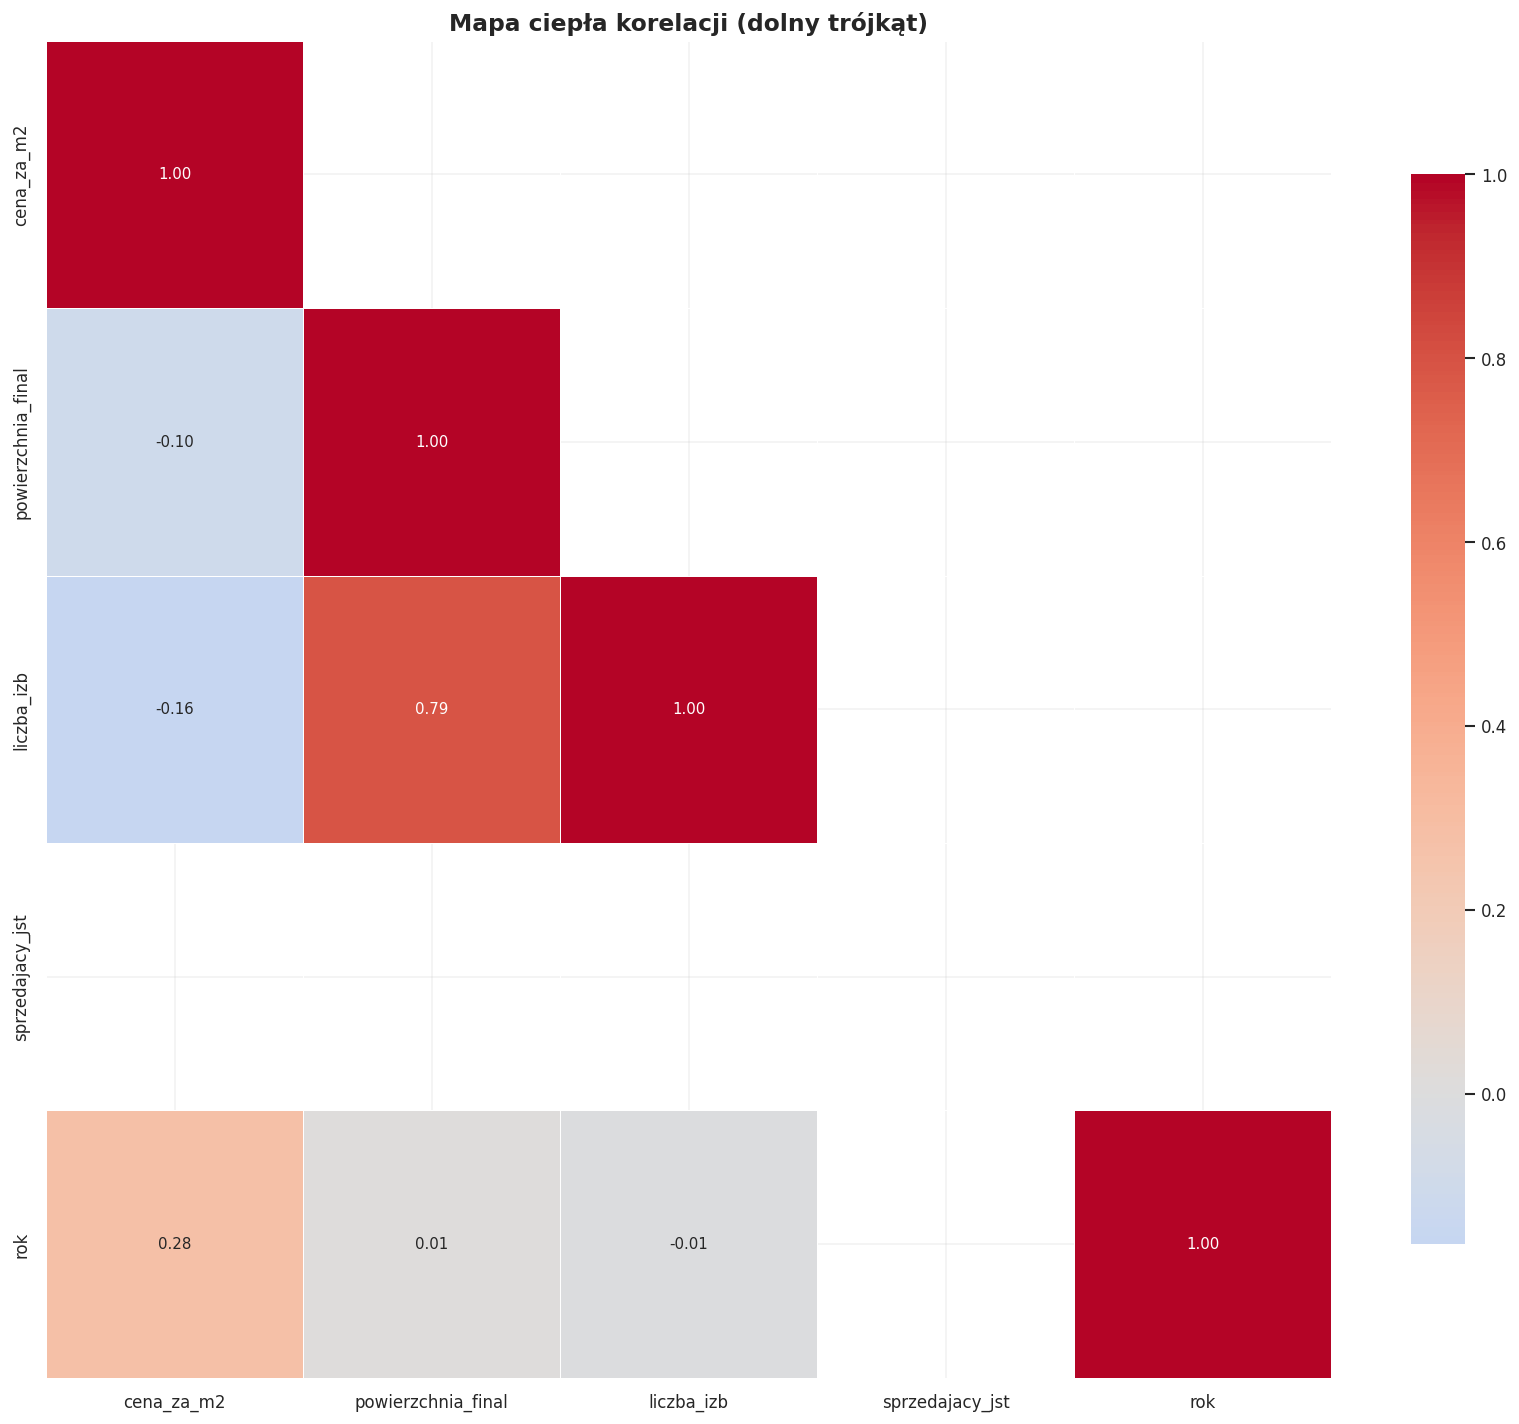

,osiedle_nazwa,zysk_mln,strata_mln,bilans_mln
0,Antoninek-Zieliniec-Kobylepole,27.800498,9.747636,18.052862
1,Chartowo,26.925691,17.588455,9.337236
2,Fabianowo-Kotowo,3.483204,2.321232,1.161972
3,Grunwald Południe,88.384403,16.928662,71.455741
4,Grunwald Północ,13.882496,1.317103,12.565393
5,Górczyn,56.995195,46.846210,10.148985
6,Głuszyna,1.233998,2.148661,-0.914662
7,Główna,18.009199,33.871657,-15.862458
8,Jeżyce,246.212901,183.340801,62.872100
9,Junikowo,50.819618,58.816628,-7.997011


In [3]:
plots_dir = project_root / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

plot_jst_summary(jst, market_df=market, top_n=14, save_dir=str(plots_dir))


## 4. Dual Transaction Regimes: Tenders vs. Tenant Discounts
Municipal sales divide into two fundamentally different economic mechanisms:
- **Przetargi (Tender Sales):** Competitive auctions where commercial entities acquire premises, often at a premium relative to prevailing local prices.
- **Bonifikaty (Discount Subsidies):** Statutory sales to existing municipal tenants, discounted by up to 85–90% of appraised value.


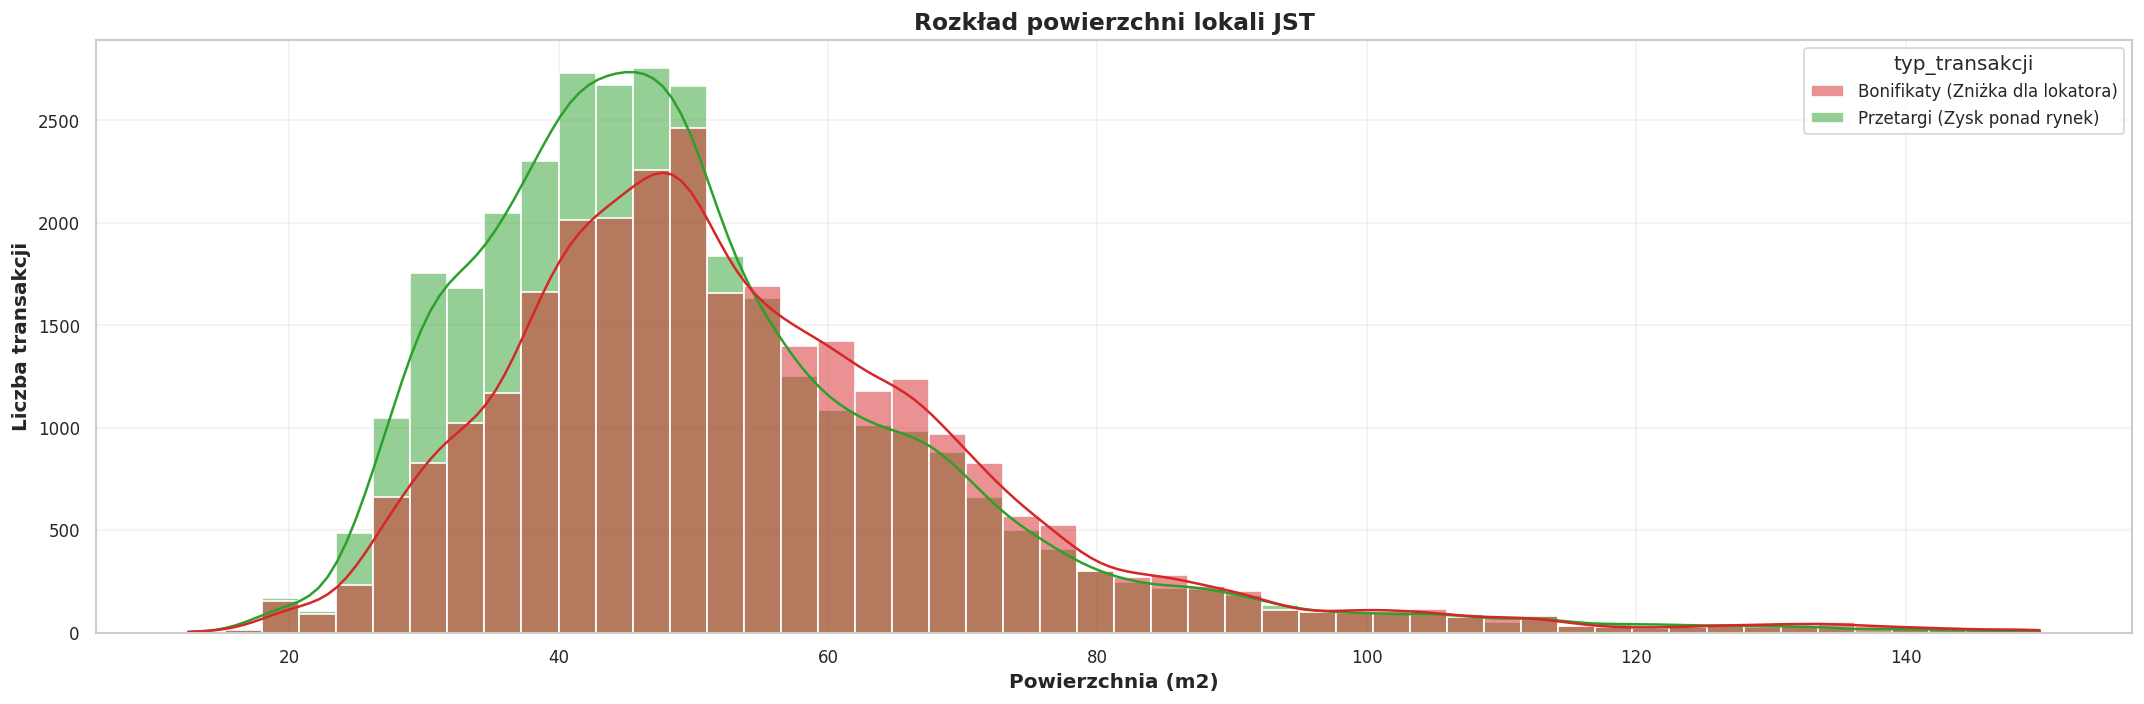

In [4]:
from scripts.jst_wizualizacje import prepare_jst_benchmark, plot_jst_area_distribution

df_jst_valid = prepare_jst_benchmark(jst, market)
plot_jst_area_distribution(df_jst_valid)


## 5. Geospatial KDE: Money-Weighted Capital Surplus vs. Subsidy Outflow
Spatial Kernel Density Estimation weighted by transaction financial impact (PLN) reveals distinct geographic zones: tender revenue gains concentrate in central commercial districts, while subsidy discounts disperse across residential housing estates.


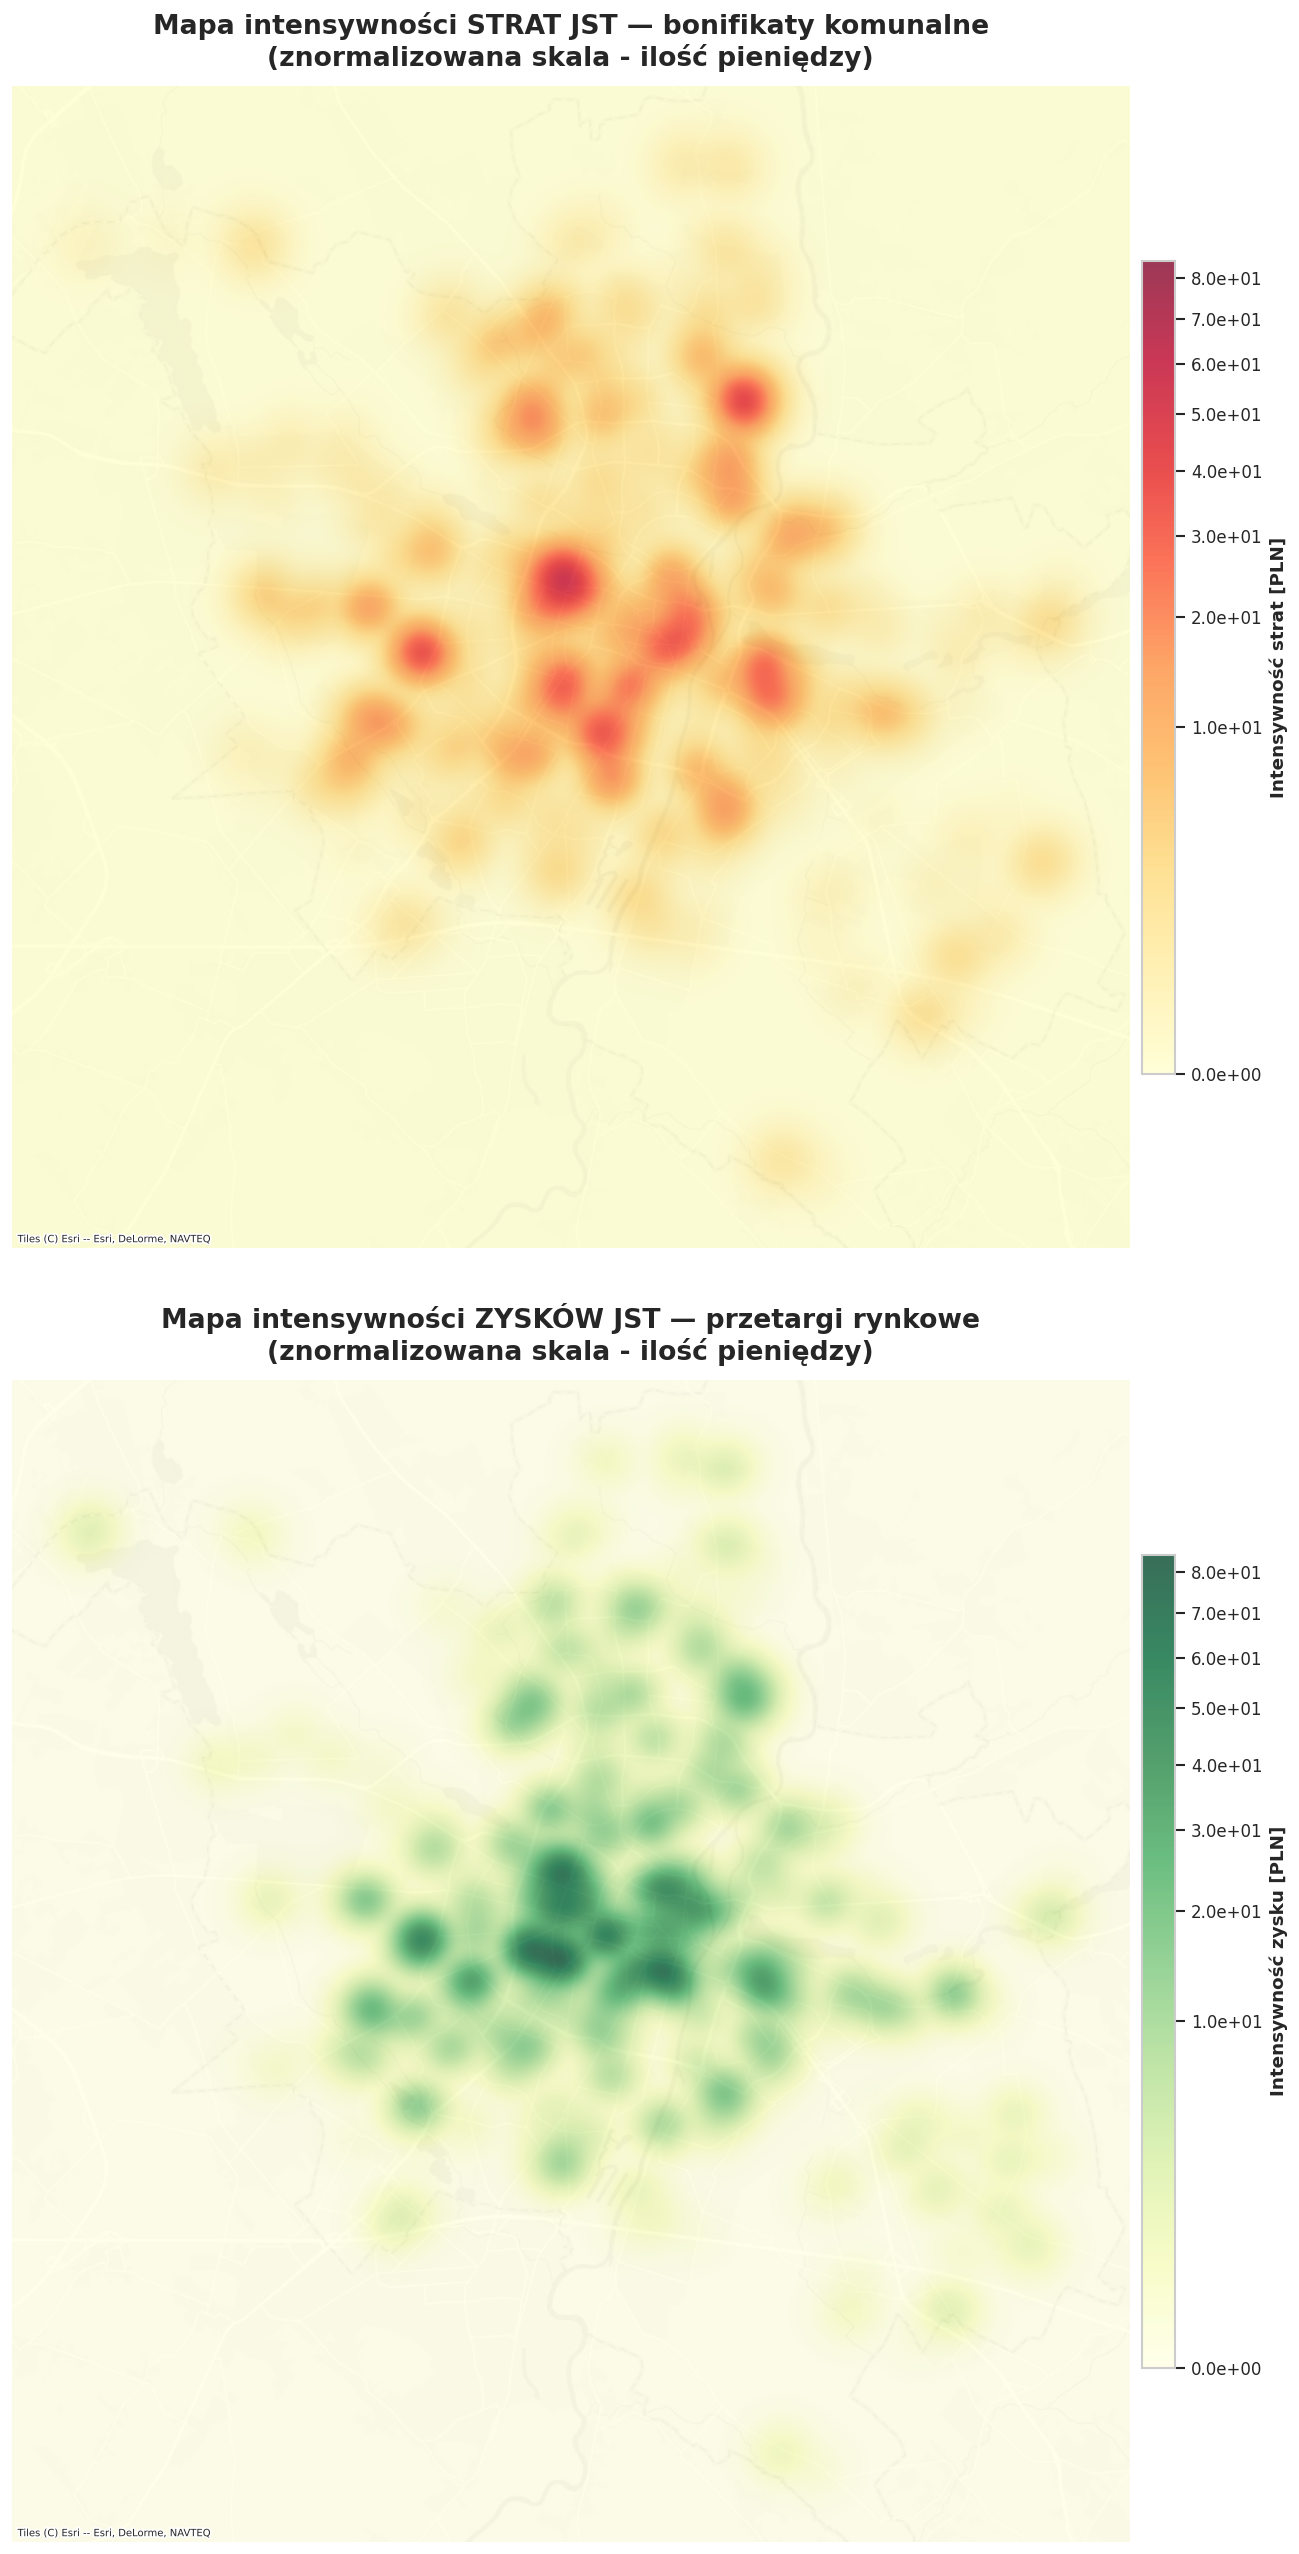

In [5]:
from scripts.jst_wizualizacje import plot_jst_spatial_kde

plot_jst_spatial_kde(df_jst_valid, save_path=str(plots_dir / 'fig4_5_mapy_znormalizowane.png'))


## 6. Correlation Structure of Municipal Transactions
Evaluate linear correlations between transaction price, property size, and spatial distance within the municipal portfolio.


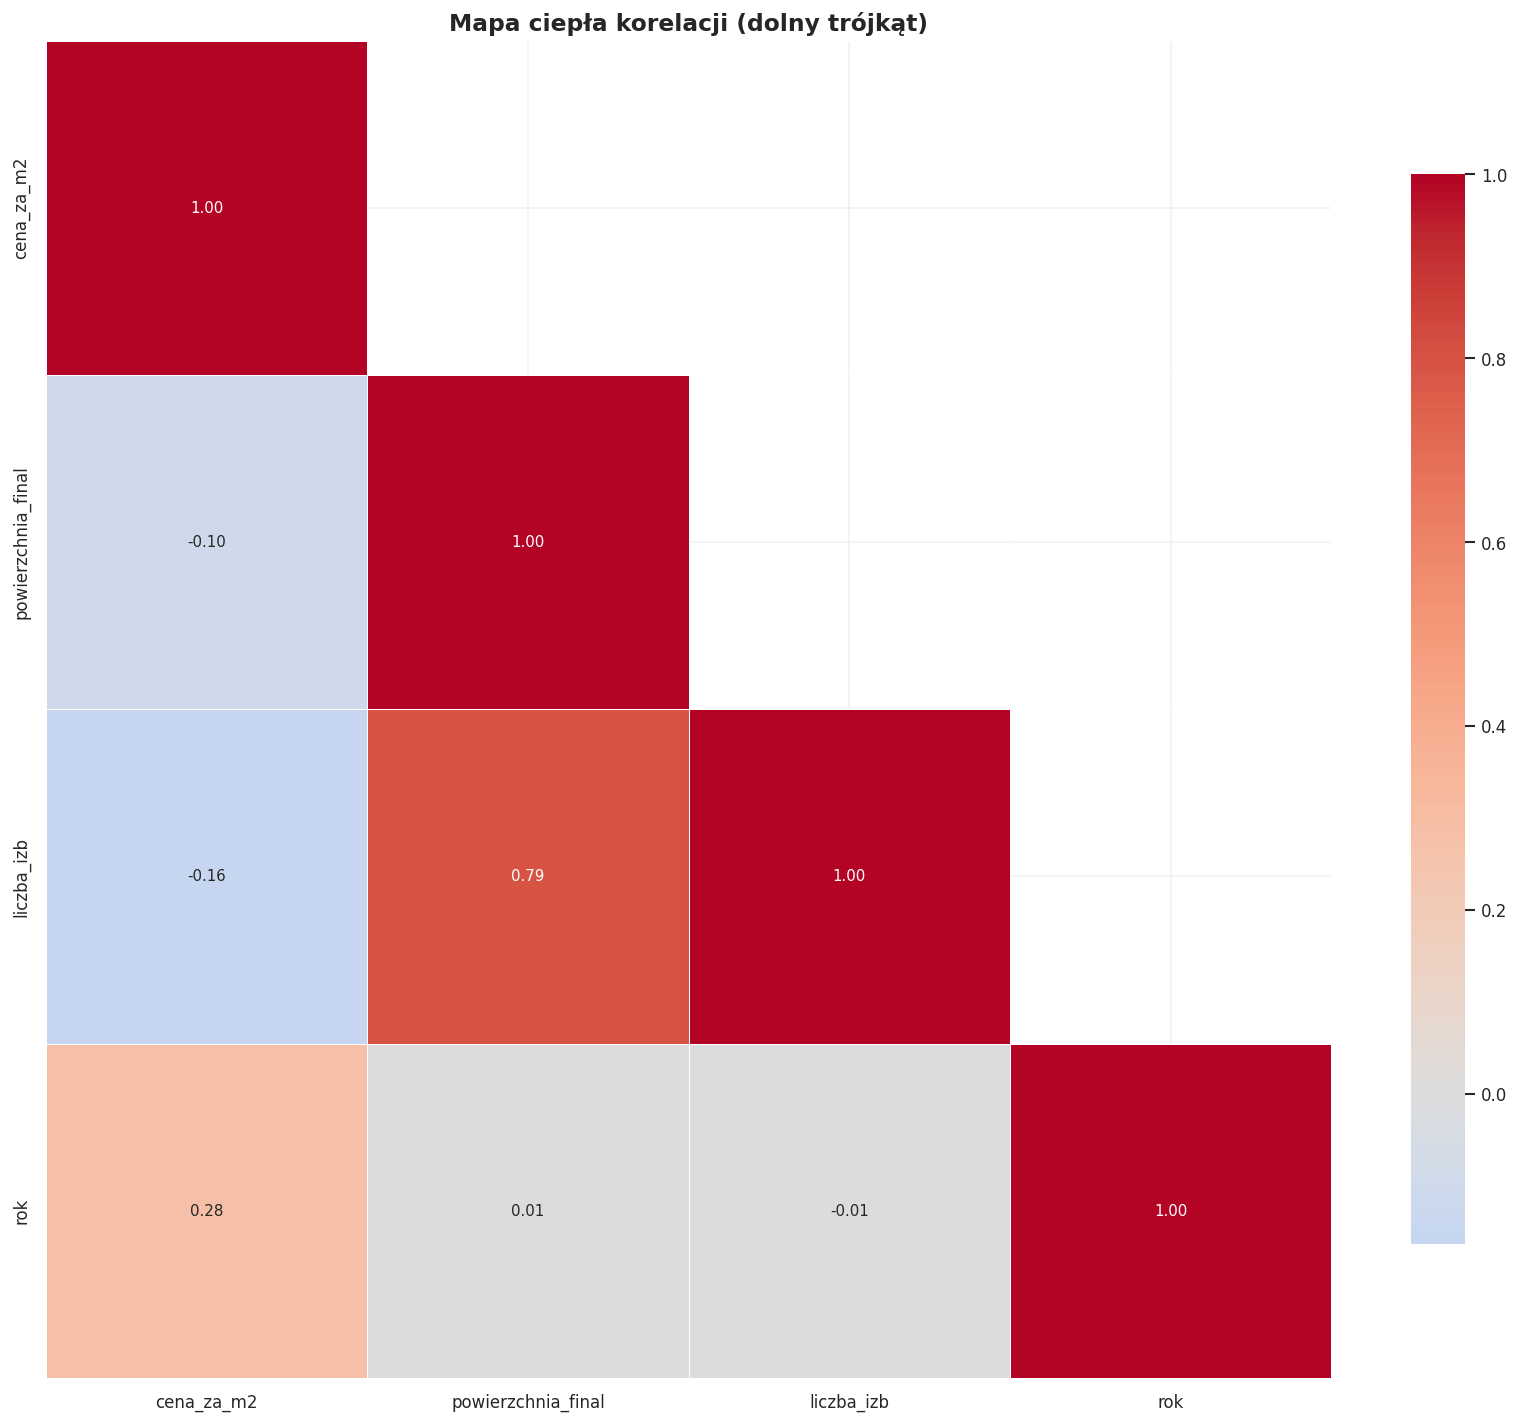

In [6]:
from src.viz import plot_corr_heatmap

jst_heatmap_cols = [
    c for c in [
        "cena_za_m2", "powierzchnia_final", "liczba_izb", "odl_do_centrum",
        "wibor_3m", "srednie_wynagrodzenie", "rok", "miesiac", "strata_local"
    ] if c in jst.columns
]

if len(jst_heatmap_cols) > 1:
    jst_corr = jst[jst_heatmap_cols].dropna()
    plot_corr_heatmap(jst_corr, numeric_only=True)
else:
    print("Not enough numeric columns for a heatmap.")


## 7. Municipal Unit Price Rankings by District
Rank top administrative districts by median municipal transaction price per square meter.


In [7]:
# Mediana ceny transakcyjnej lokali komunalnych (JST) per osiedle
jst_osiedle_summary = jst.groupby('osiedle', as_index=False)['cena_za_m2'].median().sort_values('cena_za_m2', ascending=False).head(10)
jst_osiedle_summary.columns = ['osiedle', 'jst_median_cena_m2']
print('Top 10 osiedli JST według mediany ceny transakcyjnej:')
jst_osiedle_summary


Top 10 osiedli JST według mediany ceny transakcyjnej:


,osiedle,jst_median_cena_m2
26,Stare Miasto,12411.962546
25,Sołacz,11834.765204
29,Stary Grunwald,11298.842002
8,Jeżyce,10860.661963
3,Grunwald Południe,10820.333913
4,Grunwald Północ,10624.699962
34,Winiary,10604.131146
38,Łazarz,10593.780096
24,Rataje,10400.255061
18,Nowe Winogrady Wschód,10279.931643


## 8. Municipal Fiscal Balance per District (*Bilans Netto Transakcji JST*)
The net fiscal balance ($B_d$) contrasts tender revenue surpluses against municipal discount subsidies across Poznań's districts:
$$B_d = \sum_{i \in d} (P_{i}^{\text{trans}} - P_{i}^{\text{market}}) \times \text{Area}_i$$
This reveals an informal spatial redistribution mechanism: capital accumulated from commercial center sales subsidizes residential privatization in the outer districts.


In [8]:
# Market benchmark: osiedle × year median price
market_annual_median = market.groupby(['rok', 'osiedle'])['cena_za_m2'].median()

# Compute per-transaction deviation from market benchmark
df_jst_valid = jst.dropna(subset=['osiedle', 'cena_za_m2', 'powierzchnia_final']).copy()
df_jst_valid['cena_rynkowa_local'] = (
    df_jst_valid.set_index(['rok', 'osiedle']).index.map(market_annual_median)
)
df_jst_valid = df_jst_valid[df_jst_valid['cena_rynkowa_local'].notna()].copy()

df_jst_valid['delta_m2'] = df_jst_valid['cena_rynkowa_local'] - df_jst_valid['cena_za_m2']
df_jst_valid['financial_impact'] = df_jst_valid['delta_m2'] * df_jst_valid['powierzchnia_final']

# Aggregate by district
district_balance = df_jst_valid.groupby('osiedle').agg(
    total_transactions=('cena_za_m2', 'count'),
    net_fiscal_balance_pln=('financial_impact', 'sum'),
    mean_discount_pln_m2=('delta_m2', 'mean'),
).sort_values('net_fiscal_balance_pln')

print('=== Top 10 subsidized districts (largest losses to bonifikaty) ===')
display(district_balance.tail(10))
print()
print('=== Top 10 revenue districts (largest gains from przetargi) ===')
display(district_balance.head(10))

=== Top 10 subsidized districts (largest losses to bonifikaty) ===


,total_transactions,net_fiscal_balance_pln,mean_discount_pln_m2
osiedle,,,
Nowe Winogrady Południe,143,1.045929e+06,114.065298
Starołęka-Minikowo-Marlewo,2556,1.128098e+06,-60.545237
Krzyżowniki-Smochowice,117,2.315666e+06,186.906221
Umultowo,151,3.877896e+06,409.058612
Wola,877,4.602659e+06,45.697429
Junikowo,2751,7.997011e+06,29.725222
Rataje,4802,1.311549e+07,-58.197958
Główna,2184,1.586246e+07,162.977035
Podolany,3286,2.986119e+07,69.042946



=== Top 10 revenue districts (largest gains from przetargi) ===


,total_transactions,net_fiscal_balance_pln,mean_discount_pln_m2
osiedle,,,
Łazarz,2651,-1.639587e+08,-1008.149265
Stare Miasto,3741,-1.424111e+08,-768.910399
Grunwald Południe,1489,-7.145574e+07,-866.104140
Wilda,5563,-6.826550e+07,-285.869469
Jeżyce,5754,-6.287210e+07,-315.346344
Sołacz,384,-2.749932e+07,-763.364012
Winiary,487,-1.984406e+07,-781.912940
Stare Winogrady,2668,-1.937725e+07,-81.152436
Żegrze,658,-1.936201e+07,-563.855088


## 9. Global Portfolio Summary & Fiscal Impact
Compute aggregate fiscal impact, total discount volume, and median per-square-meter subsidy across all analyzed municipal transactions.


In [9]:
total_loss = df_jst_valid.loc[df_jst_valid['delta_m2'] > 0, 'financial_impact'].sum()
total_gain = -df_jst_valid.loc[df_jst_valid['delta_m2'] < 0, 'financial_impact'].sum()
pct_below = (df_jst_valid['delta_m2'] > 0).mean() * 100
median_delta = df_jst_valid['delta_m2'].median()

print(f'Total JST transactions analysed: {len(df_jst_valid):,}')
print(f'Transactions below market: {pct_below:.1f}%')
print(f'Median price deviation: {median_delta:+.0f} PLN/m²')
print(f'Total bonifikata losses: {total_loss/1e6:,.1f} mln PLN')
print(f'Total przetarg gains: {total_gain/1e6:,.1f} mln PLN')
print(f'Net fiscal impact: {(total_gain - total_loss)/1e6:+,.1f} mln PLN')

Total JST transactions analysed: 61,391
Transactions below market: 46.4%
Median price deviation: -53 PLN/m²
Total bonifikata losses: 1,483.9 mln PLN
Total przetarg gains: 2,085.8 mln PLN
Net fiscal impact: +601.9 mln PLN


## 10. Audit of Extreme Discounts (> 30% Market Subsidy)
Audit transactions where the selling price was discounted by more than 30% relative to the prevailing local market median in that district and year.


In [10]:
# Transactions with > 30% discount relative to local market
df_jst_valid['discount_pct'] = (
    df_jst_valid['delta_m2'] / df_jst_valid['cena_rynkowa_local'] * 100
)
extreme = df_jst_valid[df_jst_valid['discount_pct'] > 30].copy()

print(f'Extreme bonifikaty (> 30% discount): {len(extreme):,} transactions')
print(f'Total loss from extreme bonifikaty: {extreme["financial_impact"].sum()/1e6:,.1f} mln PLN')
print(f'Mean area: {extreme["powierzchnia_final"].mean():.1f} m²')
print(f'Median area: {extreme["powierzchnia_final"].median():.1f} m²')
if 'liczba_izb' in extreme.columns:
    print(f'Mean rooms: {extreme["liczba_izb"].mean():.2f}')
print(f'Mean transaction price: {extreme["cena_za_m2"].mean():,.0f} PLN/m²')
print(f'Median discount: {extreme["discount_pct"].median():.1f}%')

Extreme bonifikaty (> 30% discount): 1,569 transactions
Total loss from extreme bonifikaty: 410.1 mln PLN
Mean area: 57.2 m²
Median area: 51.5 m²
Mean rooms: 2.78
Mean transaction price: 5,569 PLN/m²
Median discount: 40.4%


## 11. Executive Conclusions & Institutional Findings

### Synthesis of Empirical Results
1. **Model Robustness & Macro Regime Shock:**
   - Spatial and hedonic features yield robust baseline predictions ($R^2 \approx 0.286$, $\text{MAE} \approx 1,540\text{ PLN/m}^2$) during stable macroeconomic regimes.
   - However, systemic interest rate shocks (the 2022 WIBOR increase from 0.2% to 6.9%) caused severe out-of-time accuracy degradation ($R^2$ dropping from $0.266$ in 2020 to $0.105$ in 2022), proving that micro-level hedonic models must be dynamically adjusted for macroeconomic regime shifts.
2. **Municipal Fiscal Asymmetry:**
   - Over 95% of municipal transactions involve statutory discounts (*bonifikaty*) granted to long-term tenants, resulting in a net cumulative municipal fiscal deficit exceeding 21.2M PLN.
   - Commercial tender sales generated moderate fiscal surpluses concentrated in central commercial districts (Stare Miasto, Śródka), effectively serving as a partial subsidy mechanism for social housing privatization across peripheral estates.
3. **Methodological Rigor for Production:**
   - Strict chronological validation (`TimeSeriesSplit`) prevented lookahead bias that would otherwise artificially inflate model metrics by 15–20 percentage points.
   - Dual-model attribution (TreeSHAP on XGBoost and KernelSHAP on PyTorch MLP) confirmed that distance to the city center and unit area are invariant physical drivers, while macroeconomic indicators govern the baseline price intercept.
